In [1]:
import pandas as pd
import warnings
import numpy as np
warnings.filterwarnings("ignore")

## Estrazione dati da MongoDB

In [2]:
from pymongo import MongoClient
from dotenv import load_dotenv
import os

In [3]:
load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

client = MongoClient(MONGO_URI)
db=client["PolymerPrediction"]
collection=db["bicerano_tg"]

#print(collection.count_documents({}))

In [4]:
docs = list(collection.find({}))
df = pd.DataFrame(docs)

# espando il dizionario "properties"
prop_df = pd.json_normalize(df["properties"])

# integro nel dataframe
df = pd.concat([df.drop(columns=["properties"]), prop_df], axis=1)

# rimuovo righe senza SMILES o Tg
df = df.dropna(subset=["smiles", "Tg"])

df.head()


,_id,polymer_name,smiles,bigsmiles,source_dataset,Tg,density
0,693593c290fac38508f81563,Poly[oxy(diethylsilylene)],*O[Si](*)(CC)CC,{<O[Si](CC)(CC)>},Bicerano_bigsmiles,130,None
1,693593c290fac38508f81564,Poly(dimethyl siloxane),*O[Si](*)(C)C,{<O[Si](C)(C)>},Bicerano_bigsmiles,152,None
2,693593c290fac38508f81565,Poly(3-butoxypropylene oxide),*CC(COCCCC)O*,"{<CC(COCCCC)O>,<C(COCCCC)CO>}",Bicerano_bigsmiles,194,None
3,693593c290fac38508f81566,Poly(4-cyclohexyl-1-butene),*CC(*)CCC1CCCCC1,{$CC(CCC1CCCCC1)$},Bicerano_bigsmiles,313,None
4,693593c290fac38508f81567,Poly[(pentafluoroethyl)ethylene],*CC(*)C(F)(F)C(F)(F)F,{$CC(C(F)(F)C(F)(F)F)$},Bicerano_bigsmiles,314,None


## Integrazione descrittori RDKit

In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

descriptor_names = [desc[0] for desc in Descriptors._descList]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
# print(descriptor_names)

def rdkit_descr(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return {d: np.nan for d in descriptor_names}
    values = calc.CalcDescriptors(mol)
    return dict(zip(descriptor_names, values))

desc_df = df["smiles"].apply(rdkit_descr).apply(pd.Series)
desc_df.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,5.736111,5.736111,0.266451,-0.810185,0.490580,16.333333,102.209,92.129,102.050091,36.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.437500,5.437500,0.283951,-0.770062,0.416300,18.500000,74.155,68.107,74.018791,24.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.472963,5.472963,0.131212,0.131212,0.487422,16.555556,130.187,116.075,130.099380,54.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.728889,1.728889,0.704974,0.704974,0.555925,27.200000,138.254,120.110,138.140851,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,12.301991,12.301991,0.173125,-5.311759,0.524716,20.555556,146.058,143.034,146.015491,54.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


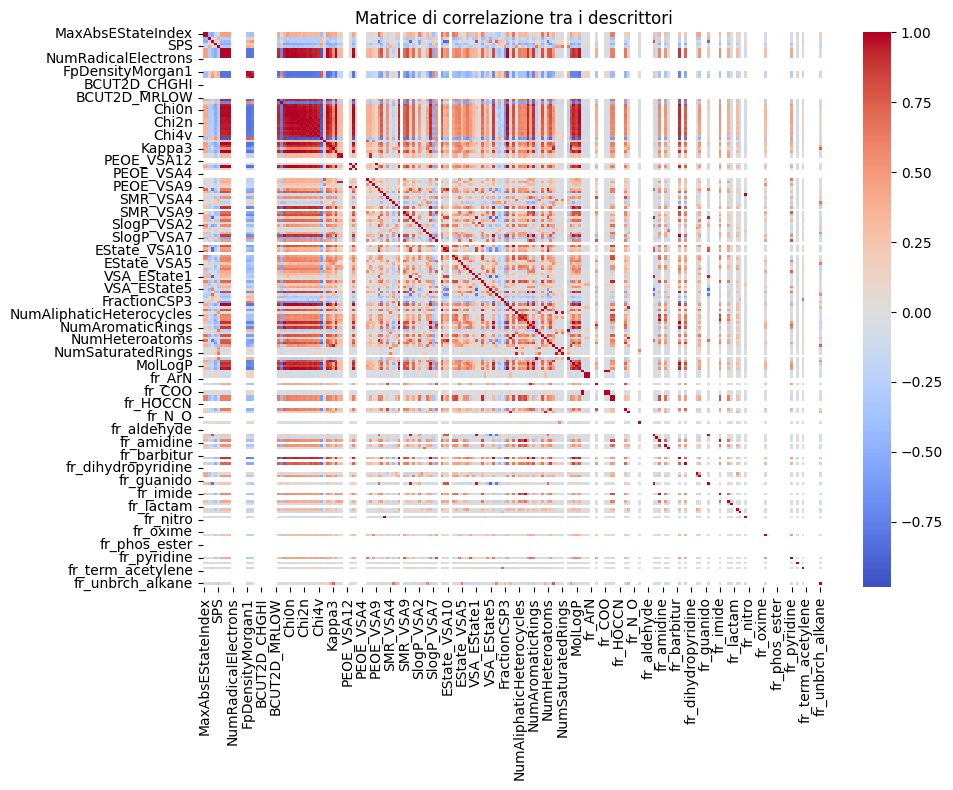

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = desc_df.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra i descrittori")
plt.tight_layout()
plt.show()

## Aggiunta Fingerprint

In [6]:
from rdkit.Chem import rdFingerprintGenerator

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def morgan_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*1024
    fp = morgan_gen.GetFingerprint(mol)  
    return list(fp)

fp_df = df["smiles"].apply(morgan_fp).apply(pd.Series)
fp_df.columns = [f"fp_{i}" for i in range(fp_df.shape[1])]

In [7]:
from rdkit.Chem import MACCSkeys

def maccs_fp(smiles):
    mol = Chem.MolFromSmiles(str(smiles))
    if mol is None:
        return [0]*167  # MACCS ha 167 bit (indice 0 inutilizzato)
    fp = MACCSkeys.GenMACCSKeys(mol)
    return list(fp)
maccs_df = df["smiles"].apply(maccs_fp).apply(pd.Series)
maccs_df.columns=[f"maccs_{i}" for i in range(167)]

feature_df = pd.concat([desc_df, fp_df, maccs_df], axis=1)

## Pulizia dei dati

In [8]:
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)
feature_df = feature_df.fillna(feature_df.median(numeric_only=True))
feature_df = feature_df.dropna(axis=1, how="all")

# --- rimuovo colonne costanti (con varianza 0) 
from sklearn.feature_selection import VarianceThreshold

sel = VarianceThreshold(threshold=0.0)
sel.fit(feature_df)

mask = sel.get_support()
feature_df = feature_df.loc[:, mask]

print("Shape:", feature_df.shape[1])


Shape: 960


## Preparazione dataset (separazione target)

In [9]:
y = df["Tg"]
X = feature_df.copy()
X.index = df["_id"]
print("Shape X:", X.shape)
print("Shape y:", y.shape)
X.sample(10)

Shape X: (304, 960)
Shape y: (304,)


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,maccs_156,maccs_157,maccs_158,maccs_159,maccs_160,maccs_161,maccs_162,maccs_163,maccs_164,maccs_165
_id,,,,,,,,,,,,,,,,,,,,,
693593c290fac38508f815bb,4.351991,4.351991,0.491759,0.491759,0.556779,16.500000,105.140,98.084,105.057849,40.0,...,1,0,0,0,0,1,1,1,0,1
693593c290fac38508f8167d,2.544306,2.544306,0.632879,0.632879,0.477046,15.375000,110.200,96.088,110.109550,46.0,...,0,0,0,0,1,0,0,0,0,0
693593c290fac38508f8161f,11.291785,11.291785,0.210745,-0.578591,0.594700,12.434783,392.065,381.985,389.938405,120.0,...,0,1,0,1,1,0,1,1,1,1
693593c290fac38508f8156e,11.661956,11.661956,0.025679,0.025679,0.606190,19.000000,170.252,152.108,170.130680,70.0,...,0,1,0,1,1,0,0,0,1,0
693593c290fac38508f81659,11.553630,11.553630,0.132400,0.132400,0.427505,17.076923,184.279,164.119,184.146330,76.0,...,0,1,0,1,1,0,0,0,1,0
693593c290fac38508f815fa,11.104192,11.104192,0.046570,-0.395444,0.807548,13.350000,268.312,252.184,268.109944,102.0,...,0,1,0,1,1,0,1,1,1,1
693593c290fac38508f815e6,2.453704,2.453704,0.463981,0.463981,0.559093,19.666667,118.179,108.099,118.078250,46.0,...,0,0,0,0,1,0,1,1,0,1
693593c290fac38508f81687,2.448565,2.448565,0.540259,0.540259,0.591866,12.500000,132.206,120.110,132.093900,52.0,...,0,0,0,0,1,0,1,1,0,1
693593c290fac38508f815fb,11.058992,11.058992,0.052264,-0.394718,0.829553,12.315789,254.285,240.173,254.094294,96.0,...,0,1,0,1,1,0,1,1,1,1


## Gradient Boosting
Anche se le colonne sono ancora tante, per farsi un'idea

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

random_state=25

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=random_state)

model_base = GradientBoostingRegressor(random_state=random_state)
model_base.fit(X_train, y_train)

pred_base = model_base.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_base))
print("R2:", r2_score(y_test, pred_base))


MAE: 37.79241105370702
R2: 0.8086328130883852


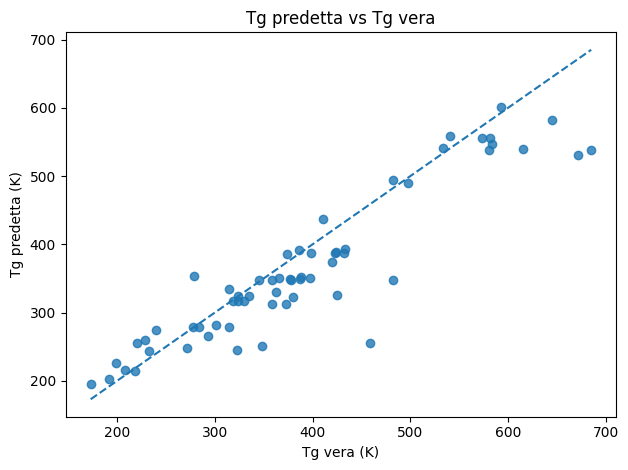

In [11]:
from matplotlib import pyplot as plt

plt.figure()
plt.scatter(y_test, pred_base, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_base.min())
max_val = max(y_test.max(), pred_base.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

## Cross validation

Per la validazione incrociata uso 5-fold CV, poiché rappresenta il miglior compromesso tra stabilità della stima e quantità di dati utilizzata per l’addestramento. Con dataset piccoli e un numero elevato di feature (come in questo caso), un numero maggiore di fold aumenterebbe la varianza delle performance e renderebbe il modello più instabile. 

In [12]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb_model = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# 8. Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 800, 'subsample': 0.8}

Best CV MAE:
24.607191623365857

Performance on Test Set:
MAE: 35.63494450261883
R² : 0.8270647562833513


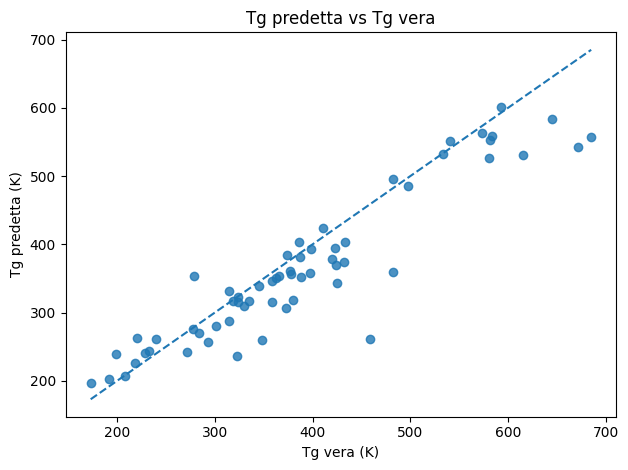

In [13]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

## Feature selection

### Mutual Info Regression

In [14]:
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, random_state=random_state)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# selezioniamo le top N feature
N = 300
top_features_mi = mi_series.head(N).index

X_mi_selected = X[top_features_mi]
print(X_mi_selected.shape)
print(X.shape)
print("Feature scelte (MI):", len(top_features_mi))

(304, 300)
(304, 960)
Feature scelte (MI): 300


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_mi_selected, y, test_size=0.2, random_state=random_state
)

model_mi = GradientBoostingRegressor(random_state=random_state)
model_mi.fit(X_train, y_train)

pred_mi = model_mi.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_mi))
print("R²:", r2_score(y_test, pred_mi))


MAE: 39.144453335144306
R²: 0.799122224873833


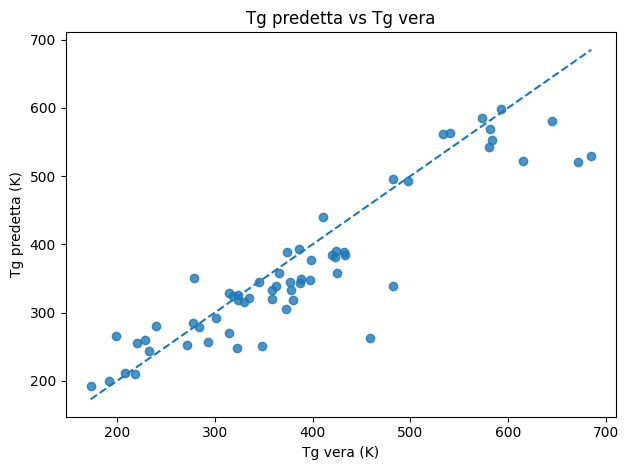

In [16]:
plt.figure()
plt.scatter(y_test, pred_mi, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_mi.min())
max_val = max(y_test.max(), pred_mi.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

### Permutation importance
Uso il modello del passaggio precedente perché serve un modello già addestrato e abbastanza buono

In [17]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

perm = permutation_importance(model_mi, X_mi_selected, y, n_repeats=10, random_state=random_state)
perm_series = pd.Series(perm.importances_mean, index=X_mi_selected.columns)
perm_series = perm_series.sort_values(ascending=False)

thr = perm_series.mean()   
selected = perm_series[perm_series > thr].index

X_perm_selected = X_mi_selected[selected]

print("Feature scelte (Permutation Importance):", X_perm_selected.shape)


Feature scelte (Permutation Importance): (304, 32)


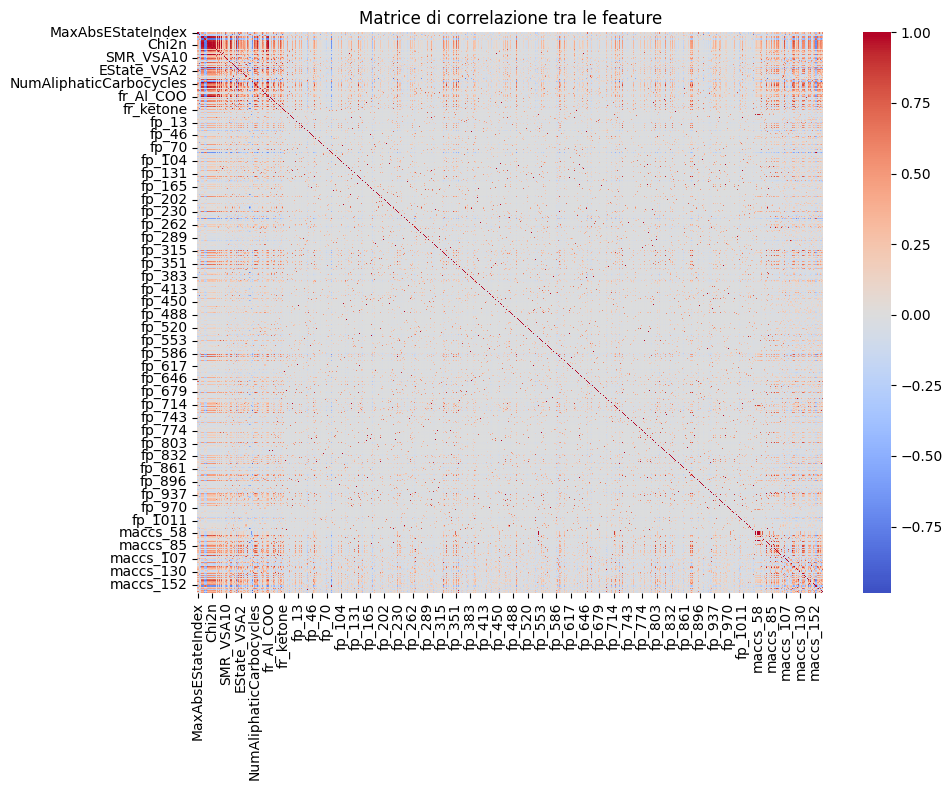

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt


corr = X.corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice di correlazione tra le feature")
plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X_perm_selected, y, test_size=0.2, random_state=random_state
)

model_perm = GradientBoostingRegressor(random_state=random_state)
model_perm.fit(X_train, y_train)

pred_perm = model_perm.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred_perm))
print("R²:", r2_score(y_test, pred_perm))


MAE: 38.2563574827986
R²: 0.8026793210215779


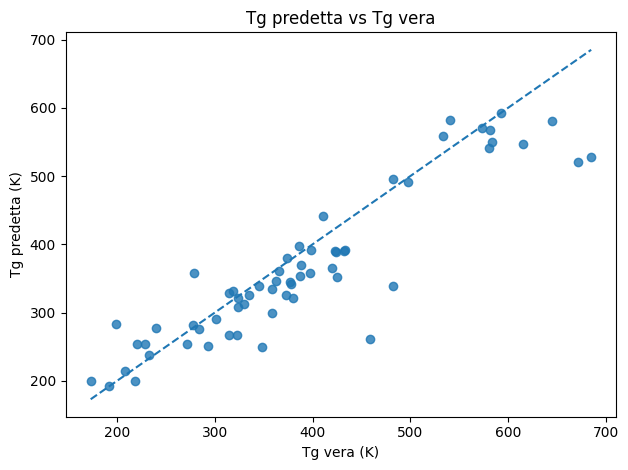

In [19]:

plt.figure()
plt.scatter(y_test, pred_perm, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred_perm.min())
max_val = max(y_test.max(), pred_perm.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

## Cross validation finale

In [20]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid = {
    "n_estimators": [200, 400, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

gb = GradientBoostingRegressor(random_state=random_state)

# Cross-validation 5 fold
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

# Grid search
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Risultati tuning
print("Best parameters found:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

# 8. Valutazione finale su test set
best_model = grid_search.best_estimator_
pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("\nPerformance on Test Set:")
print(f"MAE: {mae}")
print(f"R² : {r2}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters found:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 800, 'subsample': 0.8}

Best CV MAE:
25.593870577948554

Performance on Test Set:
MAE: 38.846472353057955
R² : 0.8068382342232956


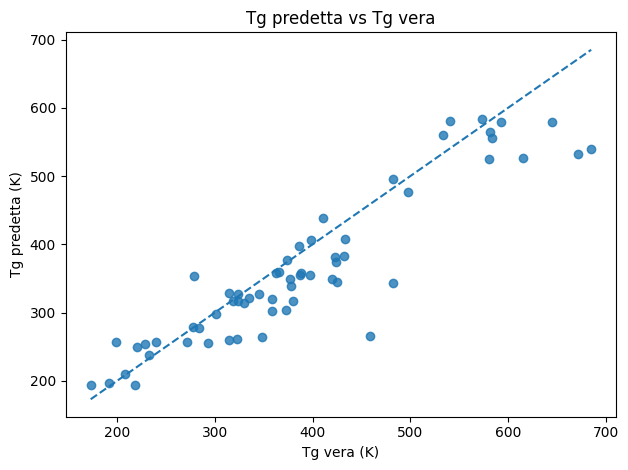

In [21]:

plt.figure()
plt.scatter(y_test, pred, alpha=0.8)


# diagonale ideale
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("Tg vera (K)")
plt.ylabel("Tg predetta (K)")
plt.title("Tg predetta vs Tg vera")

plt.tight_layout()
plt.show()

### UMAP

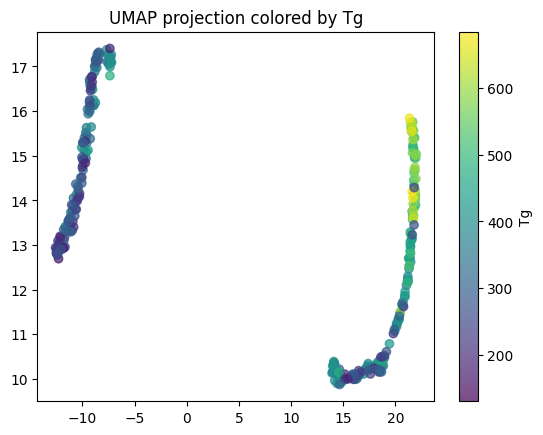

In [30]:
import umap

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    random_state=42
)

X_umap = reducer.fit_transform(X)

plt.scatter(X_umap[:,0], X_umap[:,1], c=y, alpha=0.7)
plt.colorbar(label="Tg")
plt.title("UMAP projection colored by Tg")
plt.show()


In [31]:
from sklearn.cluster import KMeans

labels = KMeans(n_clusters=2, random_state=42).fit_predict(X_umap)

In [32]:
df_umap = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])
df_umap["cluster"] = labels
df_umap["Tg"] = y.values

df_umap.groupby("cluster")["Tg"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,132.0,297.257576,75.481318,130.0,225.75,305.0,359.25,482.0
1,172.0,409.151163,116.159300,188.0,328.75,399.5,493.00,685.0


In [38]:
X_clustered = X.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

Ipc                    9.594708e+11
BertzCT                6.909624e+02
MolWt                  1.942521e+02
ExactMolWt             1.941017e+02
HeavyAtomMolWt         1.874380e+02
LabuteASA              8.331322e+01
PEOE_VSA14             8.134531e+01
NumValenceElectrons    7.049930e+01
MolMR                  5.445033e+01
SMR_VSA7               5.296791e+01
dtype: float64

In [39]:
from sklearn.preprocessing import StandardScaler

X_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X),
    columns=X.columns,
    index=X.index
)
X_clustered = X_scaled.copy()
X_clustered["cluster"] = labels

cluster_means = X_clustered.groupby("cluster").mean()
(cluster_means.loc[1] - cluster_means.loc[0]).abs().sort_values(ascending=False).head(10)

FpDensityMorgan1    1.452295
FpDensityMorgan2    1.396478
AvgIpc              1.376357
Kappa2              1.278157
PEOE_VSA14          1.249846
Kappa1              1.249809
maccs_162           1.241366
Chi3n               1.240915
Chi1n               1.240453
Chi0n               1.236661
dtype: float64

### Univariate regression - Analisi dei descrittori (solo per esplorazione)

In [24]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

scores = []

for col in X.columns:
    X_col = X[[col]]  # solo 1 descrittore
    
    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X_col, y, test_size=0.2, random_state=random_state
    )
    
    # modello semplice (va benissimo RF)
    model = RandomForestRegressor(n_estimators=200, random_state=random_state)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    
    scores.append({
        "feature": col,
        "MAE": mae,
        "R2": r2
    })

import pandas as pd
results = pd.DataFrame(scores)
results_sorted = results.sort_values("MAE")
results_sorted.head(20)

,feature,MAE,R2
107,RingCount,56.892444,0.690723
28,HallKierAlpha,57.507265,0.680975
94,NumAromaticRings,60.550109,0.641293
14,BalabanJ,62.005804,0.482701
126,fr_benzene,63.035432,0.592302
92,NumAromaticCarbocycles,63.035432,0.592302
50,SMR_VSA7,63.998176,0.585802
44,SMR_VSA10,64.435989,0.584989
60,SlogP_VSA6,64.457527,0.557760
862,maccs_62,65.100171,0.600749


In [25]:
results.sort_values("R2", ascending=False).head(20)

,feature,MAE,R2
107,RingCount,56.892444,0.690723
28,HallKierAlpha,57.507265,0.680975
94,NumAromaticRings,60.550109,0.641293
80,VSA_EState6,65.393598,0.615031
862,maccs_62,65.100171,0.600749
92,NumAromaticCarbocycles,63.035432,0.592302
126,fr_benzene,63.035432,0.592302
50,SMR_VSA7,63.998176,0.585802
44,SMR_VSA10,64.435989,0.584989
896,maccs_101,66.808565,0.577864


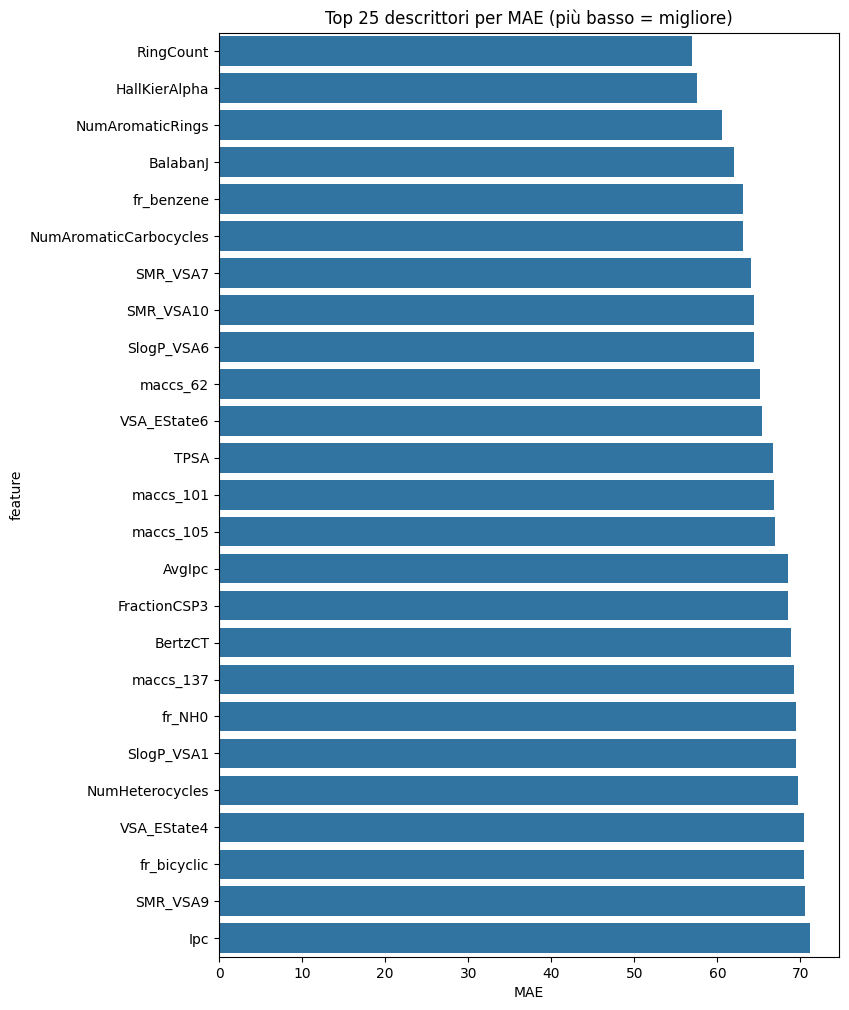

In [27]:

plt.figure(figsize=(8,12))
sns.barplot(data=results_sorted.head(25), x="MAE", y="feature")
plt.title("Top 25 descrittori per MAE (più basso = migliore)")
plt.show()
